# Business Performance Visualization Dashboard (Matplotlib)

## Projenin Amacı:
Bir şirketin iş performansını (aylık satışlar, ürün bazlı gelirler, bölge bazlı performans) **Matplotlib** kullanarak anlaşılır grafiklerle görselleştirmektir.

## Veri Görselleştirme Neden Önemlidir?
- Hızlı karar almayı sağlar. Tablolardaki binlerce satırı okumak yerine, trendleri saniyeler içinde görebiliriz.
- Satışlardaki ani düşüşler veya beklenmedik artışlar grafiklerde hemen göze çarpar (Anomaliler).
- Veriye dayalı önerilerin kabul görme şansını arttırır.

## Kullanılan Matplotlib Teknikleri:
- **Temel Grafikler:** Çizgi (Line) ve Sütun (Bar) grafikleri.
- **Grafik Özelleştirme:** Başlıklar, eksen etiketleri, renk paletleri ve ızgara (grid) yapısı.
- **Subplots:** Birden fazla analizi tek bir figür üzerinde toplama.

### 2- Veri Hazırlığı (Python/Numpy/Pandas)

In [9]:
import numpy as np
import pandas as pd

#Aylar listesi
months = ["January", "February", "March", "April","May","June","July","August","September","October", "November", "December"]

#Aylık satış verisi
monthly_sales = np.array([10000, 23000, 56000, 120000, 321000, 490000, 125690, 398991, 434000, 90288, 11220, 54000])

#Ürün bazlı gelirler
products_revenue = {
    "Laptop" : 290000,
    "Mouse" : 40000,
    "Phone": 134500,
    "TV" : 300000,
    "Tablet" : 190288,
    "Headphones" : 80000
}

#bölge bazlı performans
regions = {
    "Marmara" : 235000,
    "Ege" : 300000,
    "İç Anadolu": 350000,
    "Karadeniz" : 190000,
    "Akdeniz": 280000,
    "Doğu Anadolu": 105000,
    "Güneydoğu Anadolu": 77000
}

#dataframe oluşturdum
df_sales = pd.DataFrame ({
    "Month": months,
    "Sales" : monthly_sales
})

product_df = pd.DataFrame(list(products_revenue.items()), columns=["Product", "Revenue"])
region_df = pd.DataFrame(list(regions.items()), columns=["Region", "Revenue"])

print("Monthly sales: ")
display(df_sales)
print(" ")

print("Product Revenue: ")
display(product_df)
print(" ")

print("Region Performance")
display(region_df)


Monthly sales: 


,Month,Sales
0,January,10000
1,February,23000
2,March,56000
3,April,120000
4,May,321000
5,June,490000
6,July,125690
7,August,398991
8,September,434000
9,October,90288


 
Product Revenue: 


,Product,Revenue
0,Laptop,290000
1,Mouse,40000
2,Phone,134500
3,TV,300000
4,Tablet,190288
5,Headphones,80000


 
Region Performance


,Region,Revenue
0,Marmara,235000
1,Ege,300000
2,İç Anadolu,350000
3,Karadeniz,190000
4,Akdeniz,280000
5,Doğu Anadolu,105000
6,Güneydoğu Anadolu,77000


### 3- Line Plot (Zaman serisi)

/var/folders/73/pzq8_4cs1_zf_vhyfy8hwl8c0000gn/T/ipykernel_44930/4257216180.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


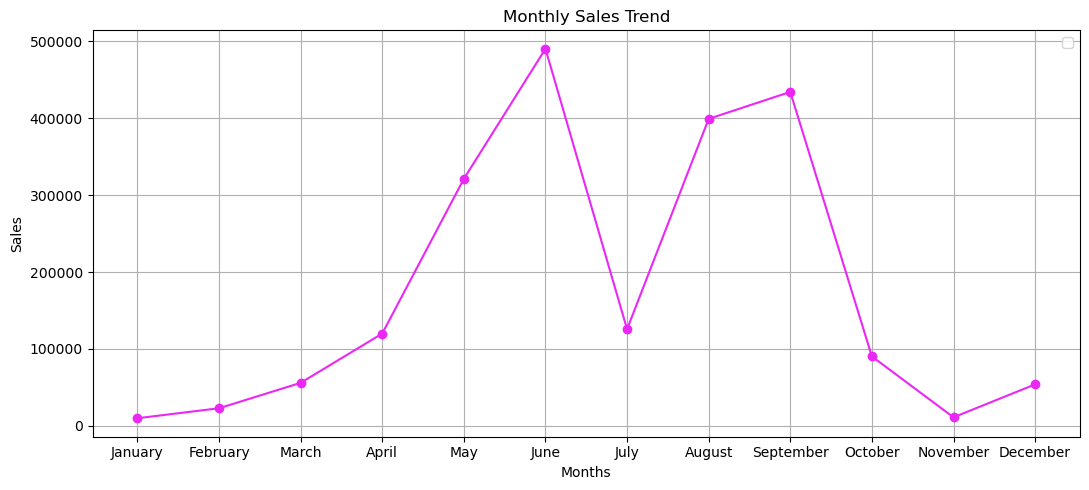

In [23]:
#Aylok satışları line chart ile göster (başlık-eksen isimleri ekle ve grid kullan)
import matplotlib.pyplot as plt
plt.figure(figsize = (11,5))
plt.plot(df_sales["Month"], df_sales["Sales"], marker="o", color="#EB27F5") #linewidth=2 faland diyerek çizgi kalınlığı da ayarlanabilir
plt.title("Monthly Sales Trend")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.grid(True) #grid yapıldı içeriğin yerleşimini düzenlemek için
plt.legend()
plt.tight_layout()
plt.show()



### 4- Bar Plot

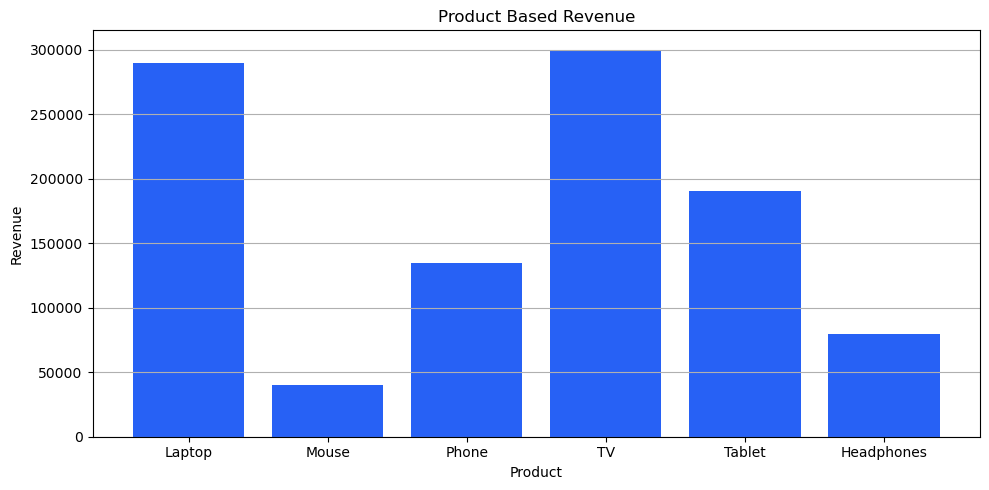

In [26]:
#Ürün bazlı satışları bar chart ile göster. Renk ve etiket özelleştir
plt.figure(figsize = (10,5))
plt.bar(product_df["Product"], product_df["Revenue"], color="#2761F5")
plt.title("Product Based Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.grid(axis="y") #yatay grid karşılaştırma için daha iyi
plt.tight_layout()
plt.show()

### 5- Grafik Özelleştirme

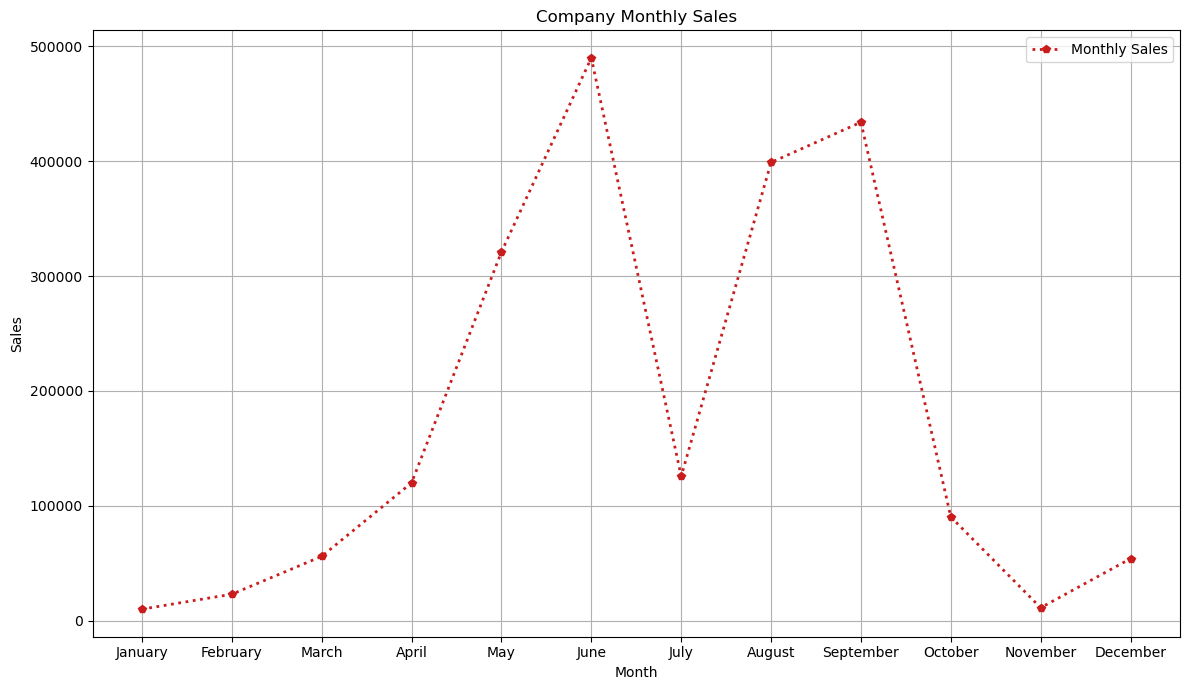

In [32]:
# title, xlabel, ylabel
# renk. çizgi tipi, marker, legend() kullanımı
plt.figure(figsize= (12,7))
#linestyle -> çizgi tipi
#legend ->grafik etiketi
plt.plot(df_sales["Month"], df_sales["Sales"], color="#C91C1C", marker ="p", linestyle=":", label="Monthly Sales", linewidth=2 )  #marke (nokta tipi) p pentagon vermeli
plt.title("Company Monthly Sales", fontsize=12)
plt.xlabel("Month", fontsize=10)
plt.ylabel("Sales", fontsize=10)
plt.grid(True)
plt.legend() #legend aktig
plt.tight_layout() #alt grafik parametrelerini otomatik ayarlar ve alana sığdırır
plt.show()


### 6- Subplots (iç içe grafikler)

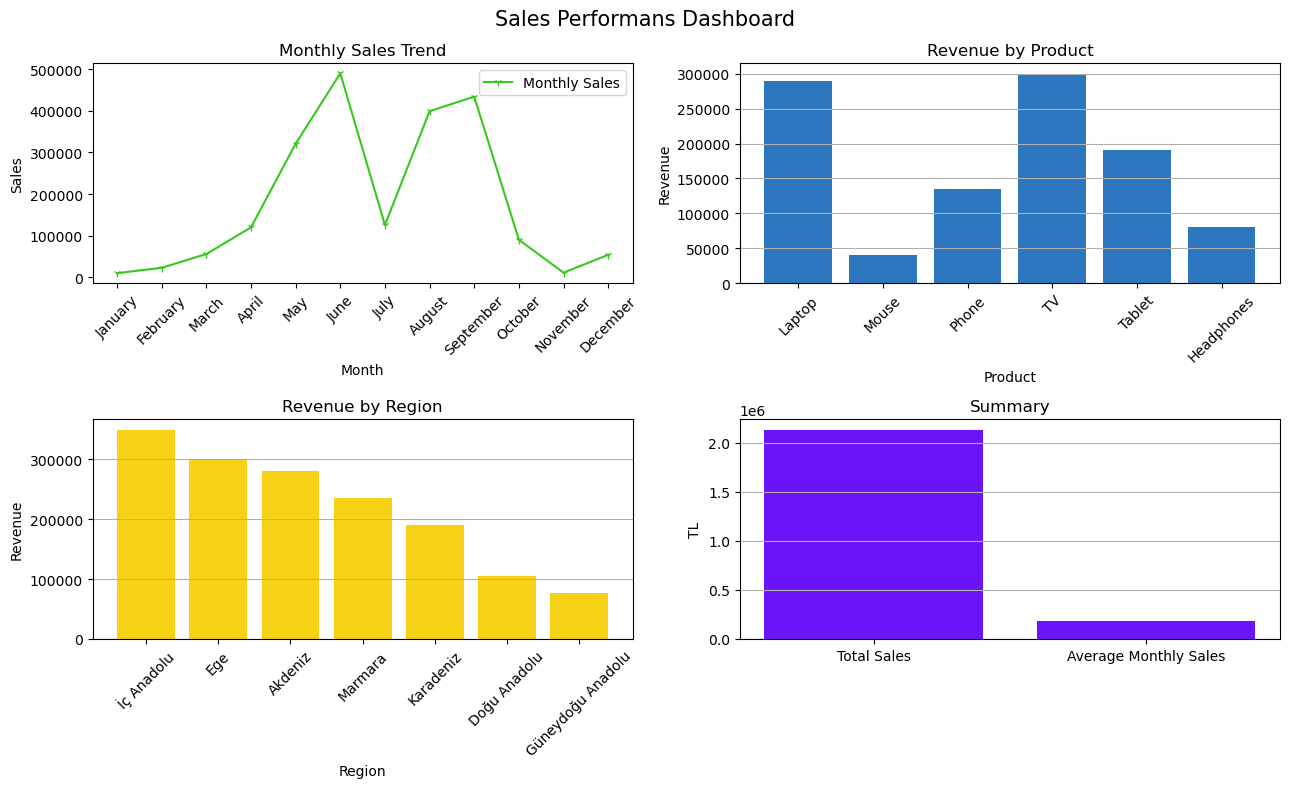

In [36]:
# 2x2 subplot oluştur
fig, ax = plt.subplots(2, 2, figsize=(13,8))


#Aynı figürde line plot, bar plot, bölge bazlı satış, genel özet grafik

#Line plot ile aylık satış (üst sola gelecek [0,0])
ax[0,0].plot(df_sales["Month"], df_sales["Sales"], marker="1", label="Monthly Sales", color="#36C91C")
ax[0,0].set_title("Monthly Sales Trend")
ax[0,0].set_xlabel("Month")
ax[0,0].set_ylabel("Sales")
ax[0,0].legend()
ax[0,0].tick_params(axis="x", rotation=45) #tick_params: eksen çizgilerinin ve etkiketlerinin parametrelerini (boyut,renk,yön) değiştirmeyi sağlar
#axis="x" -> bu değişiklik sadece yatay (x) ekseninde olacak
#rotation=45 etiketleri 45 derece açıyla döndürür

#Bar plot [0,1] sağ üstte olacak ve ürün bazlı gelir getirecek
ax[0,1].bar(product_df["Product"], product_df["Revenue"], color="#2C76BF")
ax[0,1].set_title("Revenue by Product")
ax[0,1].set_xlabel("Product")
ax[0,1].set_ylabel("Revenue")
ax[0,1].grid(axis="y")
ax[0,1].tick_params(axis="x", rotation=45)


# bar plot - bögle bazlı performans  [1,0] sol altta olacak
region_sorted = region_df.sort_values(by="Revenue", ascending=False) #büyü fiyattan küçüğe göre sıraladık
ax[1,0].bar(region_sorted["Region"], region_sorted["Revenue"], color="#F7D114")
ax[1,0].set_title("Revenue by Region")
ax[1,0].set_xlabel("Region")
ax[1,0].set_ylabel("Revenue")
ax[1,0].grid(axis="y")
ax[1,0].tick_params(axis="x", rotation=45)

 
#Genel özet grafik [1,1] sağ alt köşede
total_sales = df_sales["Sales"].sum() #toplam satıs
avg_sales = df_sales["Sales"].mean() #ortalama satıs
ax[1,1].bar(["Total Sales", "Average Monthly Sales"],[total_sales, avg_sales], color="#6B14F7")
ax[1,1].set_title("Summary")
ax[1,1].set_ylabel("TL")
ax[1,1].grid(axis="y")

#Genel başlık
fig.suptitle("Sales Performans Dashboard", fontsize=15)
plt.tight_layout()
plt.show()

# Yönetici Yorumu

## Aylık Trend Analizi
- En yüksek satışın gerçekleştiği ay -> **Haziran**
- Haziran'dan Temmuz'a sert düşüş yaşanmış.
- Ağustos ve Eylül aylarında satış tekrar yükselmiş.
- En düşük ay **Kasım** olmuş.

### Yorum: 
- Haziran büyük ihtimalle kampanya etkisine sahipti.
- Satışlar istikrarlı gitmemiş.

### Karar:
- Haziran'daki strateji analiz edilmeli (kampanya mı? reklam mı? )
- Temmuz ve Kasım için gerekiyorsa kampanya veya iyi reklam yapılmalı.
- Satış istikrarlı hale geitirlmeli yani sürdürülebilir şekilde büyümeli.


## Ürün Performansı
- En yüksek geliri getiren ürün TV olmuş.
- Hemen sonrasında da Laptop gelir getirmiş.
- Tablet ve Phone ortalama şekilde satmış.
- Özellikle headphones ve mouse düşük katkı sağlamış.

### Yorum:
- Gelir birkaç ürüne bağımlı.
- Özellikle TV önde.
- Aksesuar kategorisi zayıf kalmış.

### Karar:
- TV çok sattığı için reklam bütçesi arttırılabilir.
- TV ve Laptop'a kampanya ile daha çok satış sağlanabilir.
- Aksesuar için strateji uygulanmalı örneğin TV alan müşteriye kulaklık indirimli satılmalı gibi.


## Bölgesel Performans
- İç Anadolu en güçlü bölge.
- Ege ve Akdeniz de iyi.
- Güneydoğu Anadolu özellikle kayıp alan olmuş.

### Karar:
- Zayıf bölgede fiyat analizi yapılmalı.
- Lojistik sorunu olabilir
- Gerekiyorsa kampanya uygulanabilir.

## GENEL ÖZET:
- Toplam satış yüksek ama ortalam aylık satış ile en yüksek satış yapılan ay arasında fark çok.
- İstikrarsız bir büyüme var yani.
- Şirketin güçlü ürünleri var özellikle de İç Anadolu, Ege ve Akdeniz'de sağlam satıyor ama satış dalgalanması yüksek ve bölgesel dengesizlikler de var.

## Sonuç:
**1-** Kaynaklar özellikle en güçlü ürüne ve bölgelere yönlendirilmeli.

**2-** Zayıf bölgelere özel strateji uygulanmalı.

**3-** İstikrarlı satış için yatırım güveni sağlanmalı.
